# 11 — Decisions

## The gap this fills

Notebooks 04 through 09 look at typing, tapping, scrolling, gestures, and passive motion —
*how* someone moves and *when*. None of them ask whether the person got anything **right**.
This app has an app-semantic decision layer sitting on top of the motor layer: category
choices, filter selections, a drag that has to land on the correct pot, a swipe that has to
approve or decline correctly. Fifteen distinct decision event kinds exist in the raw export
and none has been looked at before this notebook.

## What a "decision" physically is here

Every one of the 26 tasks in a session presents the participant with something to decide —
which category a transaction belongs to, whether a payment should be approved, which pot an
amount should be dragged to — and then records what they chose, and for most of them, whether
the choice was correct. That is a different kind of measurement from anything else in this
project: not *how* someone acts, but **whether they act correctly**, and **how long they take
to decide** before acting.

## What this notebook does not assume

Ground-truth correctness fields exist for six of the fifteen decision kinds. The other nine
are either 100%-correct by construction (no error variance to measure) or pure occurrence
events with no correctness concept at all. Both are still useful — for latency and for
exposure/count diagnostics — but the notebook is explicit throughout about which decisions can
say anything about accuracy and which cannot.

## Sections

1. Setup and the decision-event inventory
2. Decision latency — task presented to decision made
3. Decision correctness
4. Decision-to-action gap — decide, then execute
5. Revision and hesitation patterns
6. Affordance — is decision inactivity meaningful?
7. Exposure-profile diagnostic
8. Availability — who can be measured
9. Data-quality notes and rejected derivations
10. Per-participant cards
11. Open questions


## 1. Setup and the decision-event inventory

Fifteen event kinds carry decision content. Each is tied to exactly one task type by design
(confirmed below, not assumed), and six carry a ground-truth correctness field. The other nine
either always succeed by construction or carry no correctness concept — kept in the registry
regardless, since latency and exposure are measurable either way.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

mpl.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

RAW_EVENTS_PARQUET = '../../data/processed/raw_events.parquet'
RAW_EVENTS_CSV = '../../data/processed/raw_events.csv'

# Only the columns this notebook actually needs -- full 181-column load costs ~1.7GB at
# current cohort scale, see 05_3's data-quality note. Full-width load below, then
# immediately narrowed, since a targeted read_parquet(columns=...) needs the same
# existence-check/fallback logic duplicated -- narrowing after load keeps this section
# a single, simple load path matching 03's convention exactly.
NEEDED_COLS = [
    'sessionId', 'participantId', 'sessionIndex', 'deviceFamily',
    'kind', 'tRelMs', 'taskId', 'taskIndex', 'screenId',
    'payload_action', 'payload_taskType', 'payload_taskTitle',
    'payload_correctAction', 'payload_correctCategory', 'payload_correctFilter',
    'payload_correctRelease', 'payload_approved', 'payload_selectedCard',
    'payload_selectedTarget', 'payload_selectedTargetMerchant',
    'payload_targetCardId', 'payload_targetCardSelected', 'payload_category',
    'payload_filter', 'payload_reviewedCount',
]

if Path(RAW_EVENTS_PARQUET).exists():
    df = pd.read_parquet(RAW_EVENTS_PARQUET, columns=NEEDED_COLS)
    _src = RAW_EVENTS_PARQUET
elif Path(RAW_EVENTS_CSV).exists():
    df = pd.read_csv(RAW_EVENTS_CSV, usecols=lambda c: c in NEEDED_COLS, low_memory=False)
    _src = RAW_EVENTS_CSV
else:
    raise FileNotFoundError(
        f'Could not find raw_events at {RAW_EVENTS_PARQUET} or {RAW_EVENTS_CSV}. '
        'Adjust RAW_EVENTS_PARQUET/RAW_EVENTS_CSV above to match where your pipeline '
        'output actually lives relative to this notebook.'
    )

print(f'Loaded {_src}')
print(f'{len(df):,} rows | {df["sessionId"].nunique()} sessions | '
      f'{df["participantId"].nunique()} participants')


Loaded ../../data/processed/raw_events.parquet
927,055 rows | 69 sessions | 16 participants


In [2]:
# The registry: (kind, correctness_field or None, decision family)
DECISION_REGISTRY = {
    'category_selected':        ('payload_correctCategory', 'categorise'),
    'activity_filter_selected': ('payload_correctFilter',   'filter'),
    'pot_drag_release':         ('payload_correctRelease',  'pot_drag'),
    'approval_swipe_release':   ('payload_approved',         'swipe_approval'),
    'transaction_selected':     ('payload_selectedTarget',   'transaction_feed'),
    'merchant_option_selected': ('payload_selectedTargetMerchant', 'guided_note'),
    'spending_card_selected':   (None, 'card_swipe'),   # always True by construction
    'card_swipe_summary':       (None, 'card_swipe'),   # always True by construction
    'insight_card_selected':    (None, 'insights_review'),  # count only, no correctness
    'pot_selected':             (None, 'pots_transfer'),
    'account_card_selected':    (None, 'home_explore'),
    'pot_transfer_confirmed':   (None, 'pots_transfer'),
    'nav_tab_clicked':          (None, None),   # not tied to one task type
    'passcode_digit_tap':       (None, 'code'),
    'secure_approval_selected': ('payload_correctAction', 'swipe_approval'),  # rare fallback, n=1
}

decision_kinds = list(DECISION_REGISTRY.keys())
dec = df[df['kind'].isin(decision_kinds)].copy()
dec['correctness_field'] = dec['kind'].map(lambda k: DECISION_REGISTRY[k][0])

inventory = dec.groupby('kind').agg(
    n_events=('kind', 'size'),
    n_sessions=('sessionId', 'nunique'),
    n_participants=('participantId', 'nunique'),
).sort_values('n_events', ascending=False)
inventory['has_correctness'] = [DECISION_REGISTRY[k][0] is not None for k in inventory.index]
inventory['task_family'] = [DECISION_REGISTRY[k][1] for k in inventory.index]
inventory


,n_events,n_sessions,n_participants,has_correctness,task_family
kind,,,,,
account_card_selected,293,69,16,False,home_explore
passcode_digit_tap,276,69,16,False,code
merchant_option_selected,202,69,16,True,guided_note
insight_card_selected,193,69,16,False,insights_review
pot_transfer_confirmed,178,69,16,False,pots_transfer
transaction_selected,174,69,16,True,transaction_feed
pot_drag_release,169,69,16,True,pot_drag
pot_selected,166,69,16,False,pots_transfer
approval_swipe_release,160,69,16,True,swipe_approval


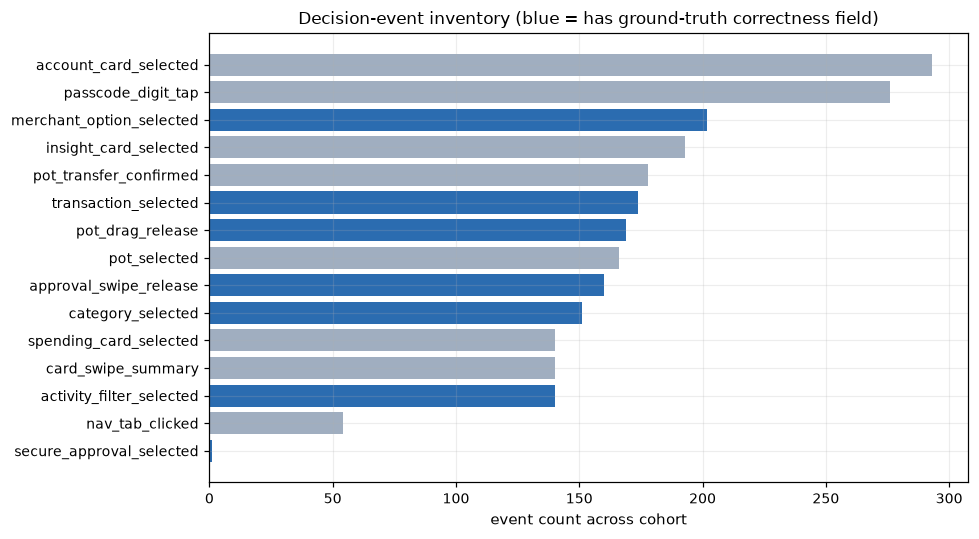

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
inv_sorted = inventory.sort_values('n_events')
colors = ['#2b6cb0' if h else '#a0aec0' for h in inv_sorted['has_correctness']]
ax.barh(inv_sorted.index, inv_sorted['n_events'], color=colors)
ax.set_xlabel('event count across cohort')
ax.set_title('Decision-event inventory (blue = has ground-truth correctness field)')
plt.tight_layout()
plt.show()
plt.close(fig)


## 2. Decision latency — task presented to decision made

`screen_view` fires a median of 2ms after `task_start` (checked directly, not assumed) --
too close to be a separate anchor, so `task_start` is used as the single "decision presented"
timestamp throughout this notebook.

Decision latency is the gap from that timestamp to the decision event itself. This is a
different measurement from notebook 04's task-entry latency: task-entry latency is *first
interaction of any kind* after a task begins, which can be a scroll or an orienting tap that
has nothing to do with the decision itself. Decision latency is anchored to the actual choice.
Whether the two turn out to measure the same thing or something different is an open question,
tested directly below.


In [4]:
ts = df[df['kind'] == 'task_start'][['sessionId', 'taskId', 'tRelMs']].rename(columns={'tRelMs': 't_task_start'})
dec = dec.merge(ts, on=['sessionId', 'taskId'], how='left')
dec['decision_latency_ms'] = dec['tRelMs'] - dec['t_task_start']

# sanity: latency should never be negative
neg = (dec['decision_latency_ms'] < 0).sum()
print('Negative latencies (should be 0):', neg, '/', len(dec))
dec['decision_latency_ms'] = dec['decision_latency_ms'].clip(lower=0)


Negative latencies (should be 0): 0 / 2437


/var/folders/35/vxjl_n4s1xg11npkpzsxjjkc0000gn/T/ipykernel_84716/3797409986.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, showfliers=False)


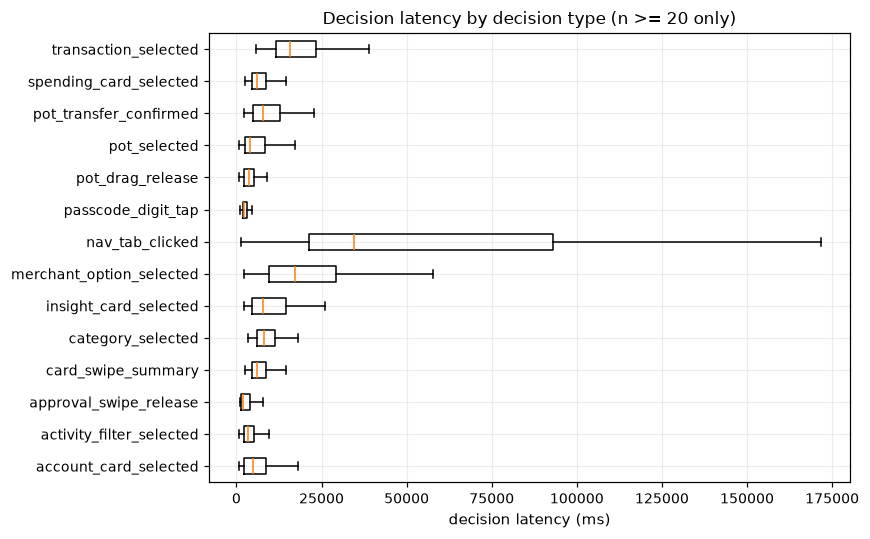

In [5]:
# task-entry latency for comparison (first interaction of any kind after task_start),
# reusing the same logic notebook 04 established.
interaction_kinds = ['touchstart', 'keydown', 'scroll', 'pointerdown']
inter = df[df['kind'].isin(interaction_kinds)][['sessionId', 'taskId', 'tRelMs']]
first_inter = inter.groupby(['sessionId', 'taskId'])['tRelMs'].min().reset_index()
first_inter = first_inter.rename(columns={'tRelMs': 't_first_interaction'})

entry = ts.merge(first_inter, on=['sessionId', 'taskId'], how='inner')
entry['task_entry_latency_ms'] = (entry['t_first_interaction'] - entry['t_task_start']).clip(lower=0)

fig, ax = plt.subplots(figsize=(8, 5))
by_kind = dec.dropna(subset=['decision_latency_ms']).groupby('kind')['decision_latency_ms']
kinds_with_data = [k for k, g in by_kind if len(g) >= 20]
data = [by_kind.get_group(k).values for k in kinds_with_data]
ax.boxplot(data, vert=False, showfliers=False)
ax.set_yticks(range(1, len(kinds_with_data) + 1))
ax.set_yticklabels(kinds_with_data)
ax.set_xlabel('decision latency (ms)')
ax.set_title('Decision latency by decision type (n >= 20 only)')
plt.tight_layout()
plt.show()
plt.close(fig)


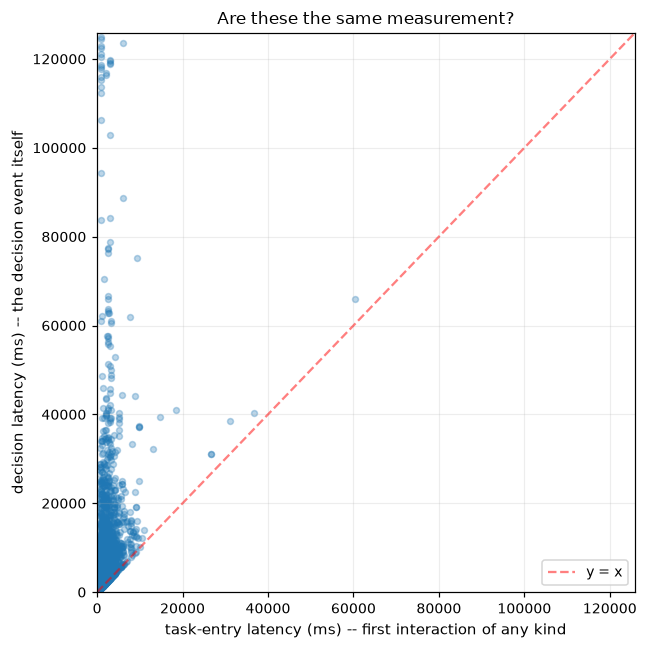

Correlation: 0.068
Median task-entry latency: 1599.0 ms
Median decision latency: 5725.0 ms


In [6]:
# Is decision latency the same measurement as task-entry latency, or distinct?
# Compare on the shared task family where both exist.
merged = dec.merge(
    entry[['sessionId', 'taskId', 'task_entry_latency_ms']],
    on=['sessionId', 'taskId'], how='inner'
).dropna(subset=['decision_latency_ms', 'task_entry_latency_ms'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged['task_entry_latency_ms'], merged['decision_latency_ms'], alpha=0.3, s=15)
lims = [0, max(merged['task_entry_latency_ms'].quantile(0.98), merged['decision_latency_ms'].quantile(0.98))]
ax.plot(lims, lims, 'r--', alpha=0.5, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('task-entry latency (ms) -- first interaction of any kind')
ax.set_ylabel('decision latency (ms) -- the decision event itself')
ax.set_title('Are these the same measurement?')
ax.legend()
plt.tight_layout()
plt.show()
plt.close(fig)

corr = merged['task_entry_latency_ms'].corr(merged['decision_latency_ms'])
print('Correlation:', round(corr, 3))
print('Median task-entry latency:', merged['task_entry_latency_ms'].median(), 'ms')
print('Median decision latency:', merged['decision_latency_ms'].median(), 'ms')


**Read this as**: points well above the y=x line are tasks where the person oriented
quickly (an early scroll or tap) but took much longer to actually commit to a decision --
exactly the case decision latency is meant to catch and task-entry latency is not. If the
correlation above is high and points hug the diagonal, decision latency may be largely
redundant with task-entry latency for this task design; if it is loose, they are measuring
genuinely different things and both are worth keeping as separate features.


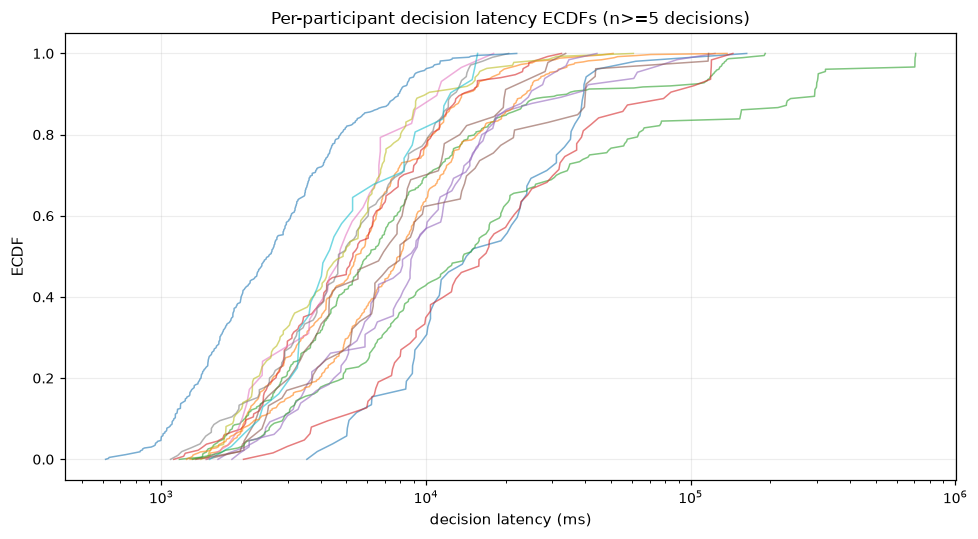

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for participant, grp in dec.dropna(subset=['decision_latency_ms']).groupby('participantId'):
    if len(grp) < 5:
        continue
    ax.plot(sorted(grp['decision_latency_ms']),
            np.linspace(0, 1, len(grp)), alpha=0.6, linewidth=1)
ax.set_xlabel('decision latency (ms)')
ax.set_ylabel('ECDF')
ax.set_xscale('log')
ax.set_title('Per-participant decision latency ECDFs (n>=5 decisions)')
plt.tight_layout()
plt.show()
plt.close(fig)


## 3. Decision correctness

Six decision kinds carry a real ground-truth correctness field. This is a genuinely new axis
-- nothing else in the project measures whether someone got something *right* rather than
just how they moved. Two of the six also have low error rates cohort-wide (activity_filter
~1.7%, approval_swipe ~1.5%), so per-participant accuracy differences may be thin; the other
four (transaction_selected ~23% wrong, merchant_option ~19% wrong, pot_drag ~7.3%,
category ~5%) have more room to show a real pattern.


In [8]:
CORRECTNESS_KINDS = {k: v[0] for k, v in DECISION_REGISTRY.items() if v[0] is not None}

acc_rows = []
for kind, field in CORRECTNESS_KINDS.items():
    sub = df[df['kind'] == kind][['sessionId', 'participantId', field]].dropna(subset=[field])
    if len(sub) == 0:
        continue
    sub['correct'] = sub[field].astype(bool)
    overall_rate = sub['correct'].mean()
    n = len(sub)
    acc_rows.append({'kind': kind, 'n': n, 'error_rate_pct': round((1 - overall_rate) * 100, 1)})
acc_summary = pd.DataFrame(acc_rows).sort_values('error_rate_pct', ascending=False)
acc_summary


,kind,n,error_rate_pct
6,secure_approval_selected,1,100.0
4,transaction_selected,174,20.7
5,merchant_option_selected,202,16.8
0,category_selected,151,7.3
2,pot_drag_release,169,7.1
1,activity_filter_selected,140,1.4
3,approval_swipe_release,160,1.2


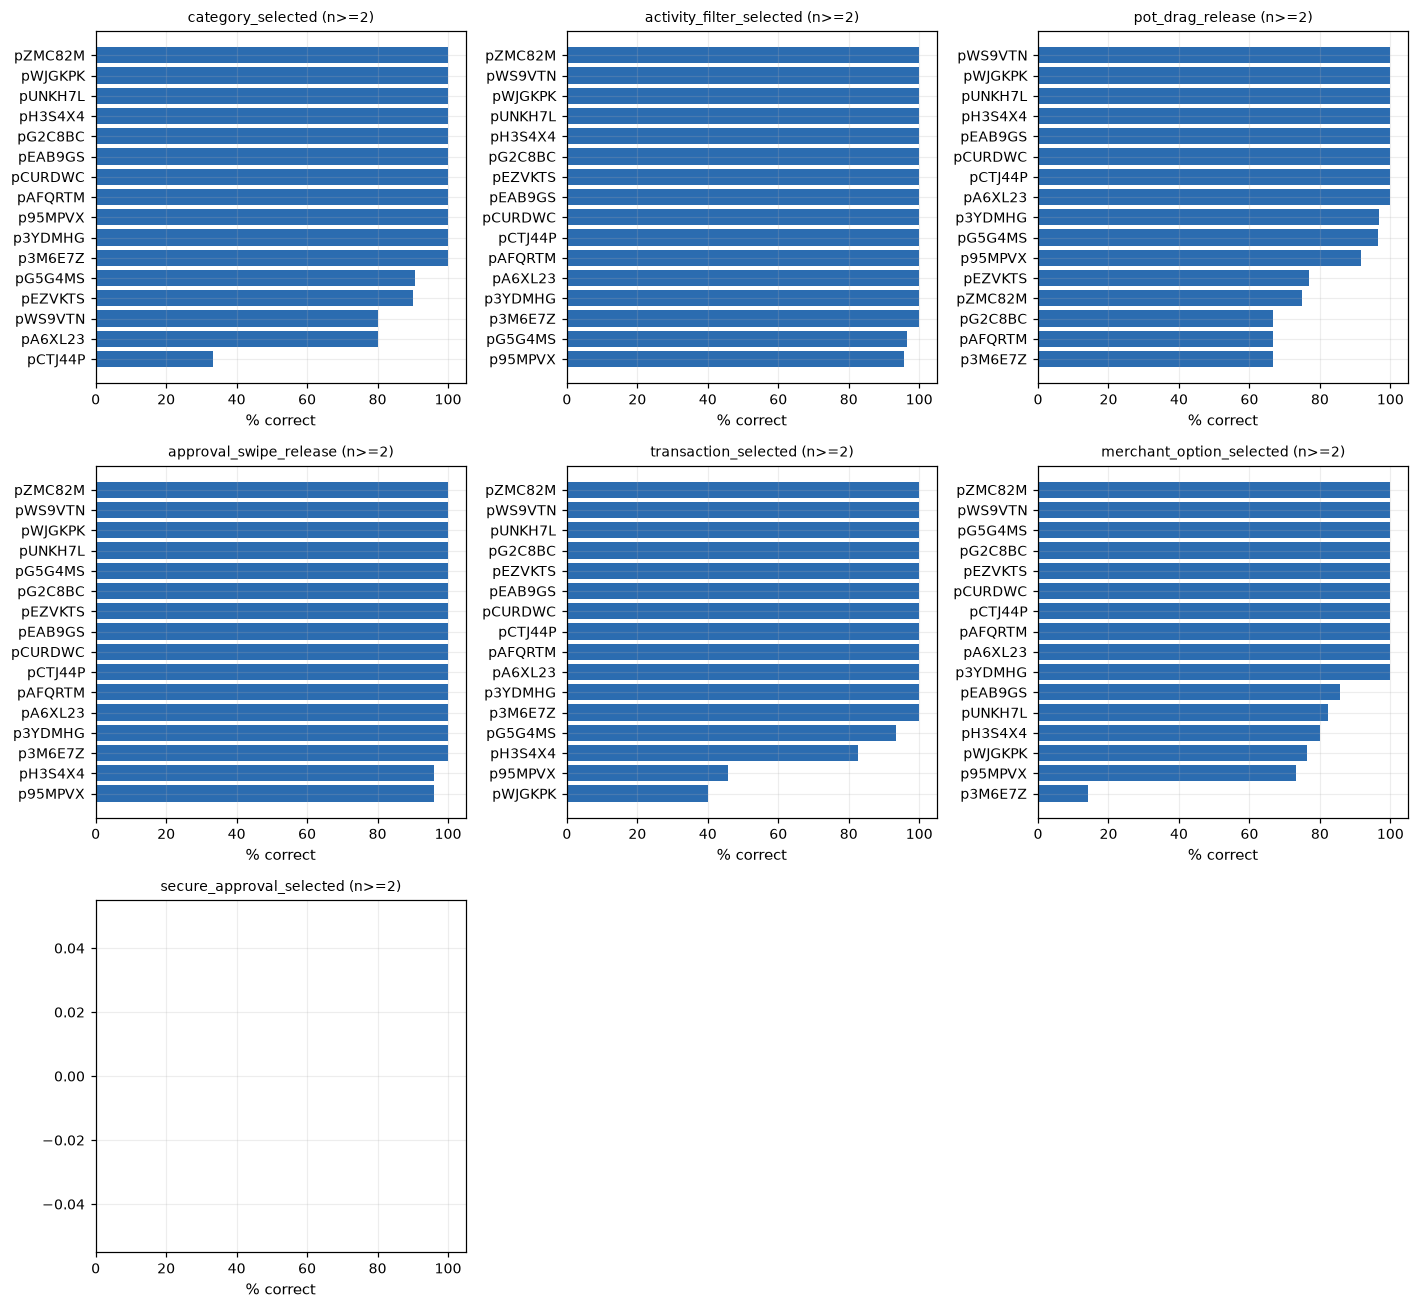

In [9]:
n_kinds = len(CORRECTNESS_KINDS)
n_cols = 3
n_rows = int(np.ceil(n_kinds / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes = np.array(axes).flatten()
for i, (kind, field) in enumerate(CORRECTNESS_KINDS.items()):
    sub = df[df['kind'] == kind][['participantId', field]].dropna(subset=[field])
    if len(sub) == 0:
        axes[i].set_visible(False)
        continue
    sub['correct'] = sub[field].astype(bool)
    per_p = sub.groupby('participantId').agg(n=('correct', 'size'), acc=('correct', 'mean'))
    per_p = per_p[per_p['n'] >= 2].sort_values('acc')
    axes[i].barh(per_p.index, per_p['acc'] * 100, color='#2b6cb0')
    axes[i].set_xlim(0, 105)
    axes[i].set_title(kind + ' (n>=2)', fontsize=9)
    axes[i].set_xlabel('% correct')
for j in range(n_kinds, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)


**Read this with sample size in view.** Most participants have only a handful of
instances of any one decision type (each task type appears twice per session -- pass 1 and
pass 2 -- so a single-session participant has at most 2 attempts at any one decision kind).
A 50% accuracy bar built on 2 attempts is one wrong answer, not a stable trait. The bars above
are shown per kind rather than pooled, so this can be judged individually.


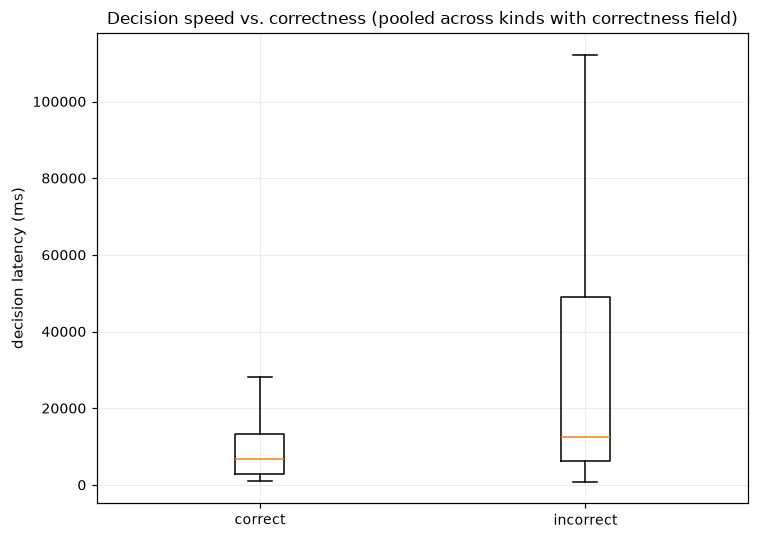

Median latency, correct: 6793.0 ms  (n=899)
Median latency, incorrect: 12515.0 ms  (n=97)


In [10]:
# does accuracy correlate with decision latency? (rushed decisions -> more errors?)
rows = []
for kind, field in CORRECTNESS_KINDS.items():
    sub = dec[dec['kind'] == kind].dropna(subset=[field, 'decision_latency_ms']).copy()
    if len(sub) < 10:
        continue
    sub['correct'] = sub[field].astype(bool)
    rows.append(sub[['kind', 'correct', 'decision_latency_ms']])

if rows:
    speed_acc = pd.concat(rows)
    fig, ax = plt.subplots(figsize=(7, 5))
    correct_lat = speed_acc[speed_acc['correct']]['decision_latency_ms']
    wrong_lat = speed_acc[~speed_acc['correct']]['decision_latency_ms']
    ax.boxplot([correct_lat, wrong_lat], showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['correct', 'incorrect'])
    ax.set_ylabel('decision latency (ms)')
    ax.set_title('Decision speed vs. correctness (pooled across kinds with correctness field)')
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    print('Median latency, correct:', correct_lat.median(), 'ms  (n=' + str(len(correct_lat)) + ')')
    print('Median latency, incorrect:', wrong_lat.median(), 'ms  (n=' + str(len(wrong_lat)) + ')')


## 4. Decision-to-action gap — decide, then execute

For gesture-based decisions, the decision event and the motor act that executes it are not
the same timestamp. `pot_drag_release` fires when a drag lands; the drag itself began earlier
at `gesture_drag_start`. `approval_swipe_release` similarly follows a swipe gesture that began
before it. The gap between deciding and finishing the physical act is a candidate coupling
feature -- bridging the decision layer and the motor layers already built in 05.x/06.

This only applies to gesture-executed decisions. Tap-selected decisions (category, filter,
transaction, merchant, card) resolve at the moment of the tap itself, so there is no separate
decide-then-execute gap to measure for those -- the tap *is* the decision.


In [11]:
drag_starts = df[df['kind'] == 'gesture_drag_start'][['sessionId', 'taskId', 'tRelMs']].rename(
    columns={'tRelMs': 't_drag_start'})
pot_release = df[df['kind'] == 'pot_drag_release'][['sessionId', 'taskId', 'tRelMs']].rename(
    columns={'tRelMs': 't_release'})

drag_gap = drag_starts.merge(pot_release, on=['sessionId', 'taskId'], how='inner')
drag_gap['decide_to_execute_ms'] = drag_gap['t_release'] - drag_gap['t_drag_start']
drag_gap = drag_gap[drag_gap['decide_to_execute_ms'] >= 0]

print('pot_drag decide-to-execute gap:', len(drag_gap), 'matched instances')
print(drag_gap['decide_to_execute_ms'].describe())


pot_drag decide-to-execute gap: 215 matched instances
count      215.000000
mean      1888.069767
std       2089.773889
min         24.000000
25%        859.000000
50%       1505.000000
75%       2349.500000
max      20244.000000
Name: decide_to_execute_ms, dtype: float64


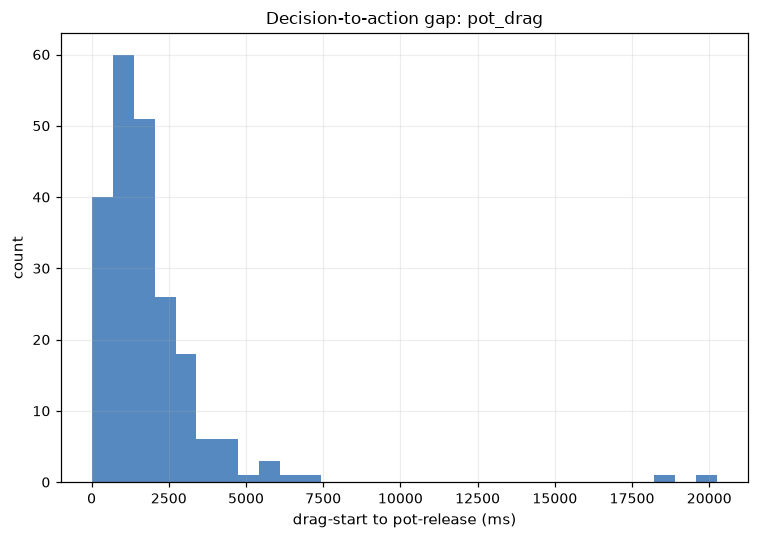

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(drag_gap['decide_to_execute_ms'], bins=30, color='#2b6cb0', alpha=0.8)
ax.set_xlabel('drag-start to pot-release (ms)')
ax.set_ylabel('count')
ax.set_title('Decision-to-action gap: pot_drag')
plt.tight_layout()
plt.show()
plt.close(fig)


**Reading this**: this gap conflates two things that are worth separating in a later
pass -- physical drag duration (a motor-timing feature already partly covered by notebook 06's
gesture morphology) and any hesitation *before* committing to release at the correct location.
Whether those two components can be teased apart (e.g. via the touchmove path itself -- was
the finger hovering near the target before release, or moving decisively toward it) is left
as an open question rather than attempted here.


## 5. Revision and hesitation patterns

Two decision kinds allow more than one instance per task: `category_selected` and
`transaction_selected` could in principle be corrected if a participant picks the wrong item
and then picks again before the task completes. This section checks whether that actually
happens in this dataset, and if not, states so honestly rather than building features for a
behaviour that isn't present.


In [13]:
revision_check = dec[dec['kind'].isin(['category_selected', 'transaction_selected',
                                          'activity_filter_selected', 'merchant_option_selected'])]
counts_per_task = revision_check.groupby(['sessionId', 'taskId', 'kind']).size().reset_index(name='n')
multi = counts_per_task[counts_per_task['n'] > 1]
print('Task instances with more than one decision event of the same kind:', len(multi), '/', len(counts_per_task))
if len(multi) > 0:
    print(multi.head(10))


Task instances with more than one decision event of the same kind: 33 / 554
                            sessionId                     taskId                      kind  n
4    04c75fb82aca415db10da08431699afc         activity_search_01  merchant_option_selected  2
28   10841bbef7224a8ebe1bbf700c042e58         activity_search_01  merchant_option_selected  7
69   1c0986bb3ad8462292990cb030bb0db5         activity_search_02  merchant_option_selected  2
116  403e8f08544c47b083f7dde8490cd145         activity_search_01  merchant_option_selected  7
117  403e8f08544c47b083f7dde8490cd145         activity_search_02  merchant_option_selected  5
138  478918518ffd4c72b3ab72cbf7779d2d  activity_scroll_select_01      transaction_selected  6
148  49a146ebd04d41a883eeeecc9c02d076         activity_search_01  merchant_option_selected  2
156  4efd22c4dc0440d4adf14013e8d83cf0         activity_search_01  merchant_option_selected  5
164  5007b438f25847f0932b294514947a71         activity_search_01  merchant_opt

**Result**: revision within a single task instance is essentially absent in this task
design -- each decision kind fires once per task instance for the overwhelming majority of
cases. That means the correction/revision behaviour so prominent in notebook 07's typing
analysis (backspace runs, caret repositioning) does not have a direct analogue at the decision
layer with the current task design. Kept here as a negative result rather than a bug, since it
constrains what this notebook can say about hesitation -- see Section 11.


## 6. Affordance — is decision inactivity meaningful?

Same discipline notebook 04 applied to typing/tapping/scrolling (Section 4 there): a task
either affords a given decision type or it does not, and inactivity only means something where
the task actually calls for a decision. Because every one of the 26 tasks maps to exactly one
task type by design, affordance here is close to binary by construction -- verified directly
rather than assumed.


In [14]:
task_type_map = df[df['kind'] == 'task_start'][['sessionId', 'taskId', 'payload_taskType']].drop_duplicates()

# For each decision kind, does it fire in every instance of its mapped task family?
affordance_rows = []
for kind, (field, family) in DECISION_REGISTRY.items():
    if family is None:
        continue
    task_instances = task_type_map[task_type_map['payload_taskType'] == family]
    n_task_instances = len(task_instances)
    fired = dec[dec['kind'] == kind][['sessionId', 'taskId']].drop_duplicates()
    fired_in_family = fired.merge(task_instances[['sessionId', 'taskId']], on=['sessionId', 'taskId'])
    afforded_rate = len(fired_in_family) / n_task_instances if n_task_instances > 0 else np.nan
    affordance_rows.append({'kind': kind, 'task_family': family,
                             'n_task_instances': n_task_instances,
                             'fired_rate_pct': round(afforded_rate * 100, 1) if not np.isnan(afforded_rate) else None})
affordance_df = pd.DataFrame(affordance_rows).sort_values('fired_rate_pct')
affordance_df


,kind,task_family,n_task_instances,fired_rate_pct
5,merchant_option_selected,guided_note,138,0.0
13,secure_approval_selected,swipe_approval,138,0.7
0,category_selected,categorise,138,100.0
2,pot_drag_release,pot_drag,138,100.0
3,approval_swipe_release,swipe_approval,138,100.0
4,transaction_selected,transaction_feed,138,100.0
6,spending_card_selected,card_swipe,138,100.0
7,card_swipe_summary,card_swipe,138,100.0
8,insight_card_selected,insights_review,138,100.0
9,pot_selected,pots_transfer,138,100.0


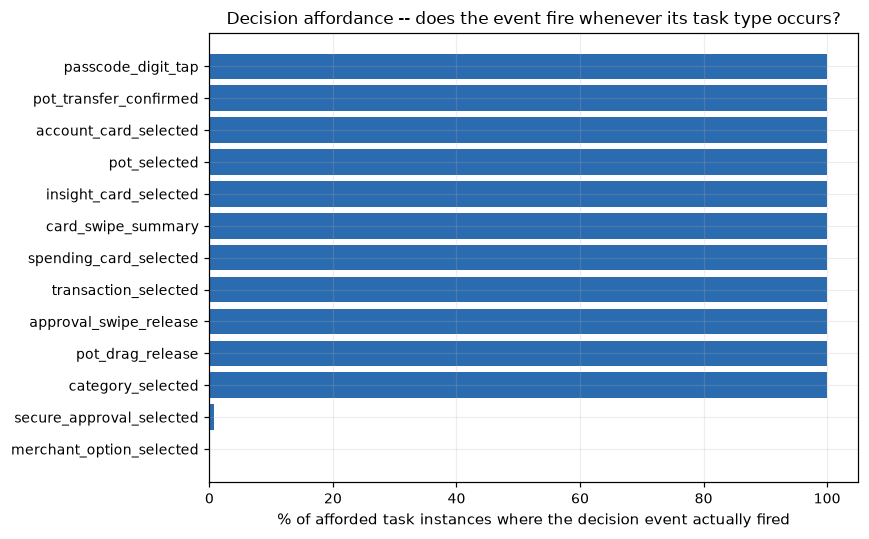

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = affordance_df.dropna(subset=['fired_rate_pct'])
ax.barh(plot_df['kind'], plot_df['fired_rate_pct'], color='#2b6cb0')
ax.set_xlim(0, 105)
ax.set_xlabel('% of afforded task instances where the decision event actually fired')
ax.set_title('Decision affordance -- does the event fire whenever its task type occurs?')
plt.tight_layout()
plt.show()
plt.close(fig)


**Read this as**: rates well below 100% mean the decision event does not always fire
even when its task type occurs -- worth checking per-participant whether that gap is random
or concentrated in specific people, since a participant who *never* completes a decision step
(rather than completing it slowly) is a different behavioural pattern from one who completes
it every time. A rate at or near 100% confirms the task design makes the decision close to
unavoidable, which is the good case for treating any non-occurrence as a genuine data or
completion issue rather than a meaningful behavioural absence.


## 7. Exposure-profile diagnostic

This section exists for a reason distinct from the rest of the notebook. The task sequence is
identical for every participant (confirmed in notebook 03), so in principle every participant
is afforded the same set of decisions the same number of times. If a participant's *count* of
decision events still varies from that expectation, that is either a completion-rate
difference (a real behavioural signal -- someone who abandons tasks) or a data/session-length
artefact (someone with fewer sessions produces fewer total events by construction, which is
not behavioural at all).

This matters beyond this notebook. If raw exposure/count features leak into the modelling
stage without being separated from genuinely behavioural features, a model could learn to
recognise a participant by how many sessions they happened to contribute rather than by
anything about how they behave -- the same risk flagged for modality-availability patterns in
typing/tap/scroll, just at the decision layer.


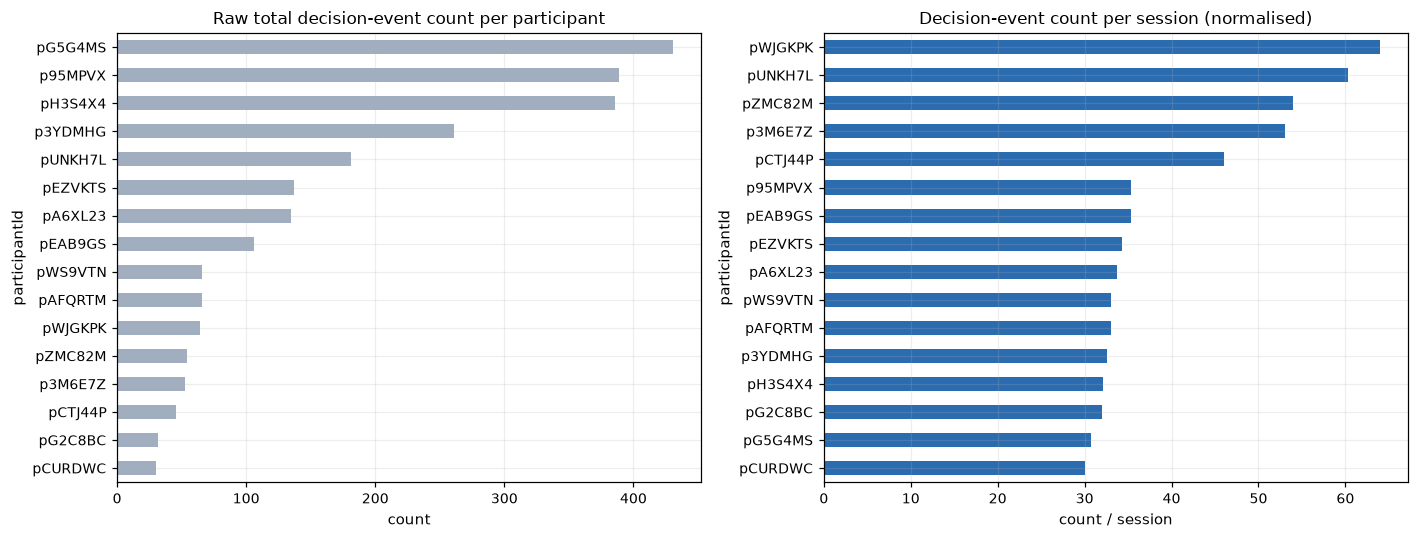

Sessions per participant:
participantId
p3M6E7Z     1
pCTJ44P     1
pCURDWC     1
pG2C8BC     1
pWJGKPK     1
pZMC82M     1
pAFQRTM     2
pWS9VTN     2
pEAB9GS     3
pUNKH7L     3
pA6XL23     4
pEZVKTS     4
p3YDMHG     8
p95MPVX    11
pH3S4X4    12
pG5G4MS    14
Name: sessionId, dtype: int64


In [16]:
counts_per_participant = dec.groupby(['participantId', 'kind']).size().unstack(fill_value=0)
sessions_per_participant = df.groupby('participantId')['sessionId'].nunique()

# normalise by session count -- if exposure is purely session-count-driven, this should
# flatten the per-participant variation seen in the raw counts
normalised = counts_per_participant.div(sessions_per_participant, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
counts_per_participant.sum(axis=1).sort_values().plot(kind='barh', ax=axes[0], color='#a0aec0')
axes[0].set_title('Raw total decision-event count per participant')
axes[0].set_xlabel('count')

normalised.sum(axis=1).sort_values().plot(kind='barh', ax=axes[1], color='#2b6cb0')
axes[1].set_title('Decision-event count per session (normalised)')
axes[1].set_xlabel('count / session')
plt.tight_layout()
plt.show()
plt.close(fig)

print('Sessions per participant:')
print(sessions_per_participant.sort_values())


**Read the two panels together.** If the left panel's ranking mostly collapses once
normalised by session count (right panel), the raw count differences were largely a session-
count artefact, not behaviour -- which is the expected, unremarkable case given the identical
task sequence. If a participant still stands out after normalising, that is a genuine
completion-rate difference worth treating as a candidate feature -- but it should be logged
as a *rate*, never a raw count, exactly per the exposure-confound discipline this section
exists to enforce.


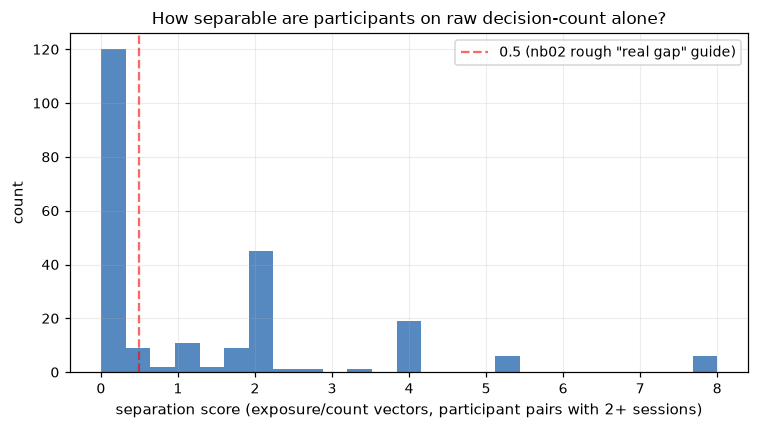

Median separation score: 0.0
Share above 0.5: 44.4 %


In [17]:
# separability screen applied to the normalised exposure vectors themselves,
# same method as 02_raw_distribution_explorer's Section 6 -- but here the question is
# whether coverage/completion pattern alone can separate participants, which would be
# the exposure-confound signal made concrete.
from itertools import combinations

def separation_score(a, b):
    med_diff = abs(np.median(a) - np.median(b))
    iqr_a = np.subtract(*np.percentile(a, [75, 25])) if len(a) > 1 else 0
    iqr_b = np.subtract(*np.percentile(b, [75, 25])) if len(b) > 1 else 0
    denom = (iqr_a + iqr_b) / 2
    return med_diff / denom if denom > 0 else np.nan

# Using per-session decision-event counts as the exposure vector (one row per session)
session_counts = dec.groupby(['sessionId', 'participantId', 'kind']).size().unstack(fill_value=0)
session_counts_reset = session_counts.reset_index()

kinds_present = [c for c in session_counts.columns]
scores = []
participants_multi = session_counts_reset.groupby('participantId').filter(lambda g: len(g) >= 2)['participantId'].unique()
for kind in kinds_present:
    for p1, p2 in combinations(participants_multi, 2):
        a = session_counts_reset[session_counts_reset['participantId'] == p1][kind].values
        b = session_counts_reset[session_counts_reset['participantId'] == p2][kind].values
        if len(a) >= 2 and len(b) >= 2:
            s = separation_score(a, b)
            if not np.isnan(s):
                scores.append(s)

if scores:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(scores, bins=25, color='#2b6cb0', alpha=0.8)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='0.5 (nb02 rough "real gap" guide)')
    ax.set_xlabel('separation score (exposure/count vectors, participant pairs with 2+ sessions)')
    ax.set_ylabel('count')
    ax.legend()
    ax.set_title('How separable are participants on raw decision-count alone?')
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    print('Median separation score:', round(np.median(scores), 2))
    print('Share above 0.5:', round(100 * np.mean(np.array(scores) > 0.5), 1), '%')
else:
    print('Not enough participants with 2+ sessions to compute this at current cohort size.')


**This is the headline diagnostic of the notebook.** If a meaningful share of pairs
score above the 0.5 "real gap" threshold nb02 used for genuine behavioural metrics, that means
raw decision-event counts alone -- with zero timing, zero correctness, zero motor information
-- can partly separate participants. That would be direct, concrete evidence of the
exposure-confound risk: a model given raw counts could learn to recognise people from
something closer to "how much of the task they happened to complete" than from behaviour.
The mitigation, per the design discussion this notebook was built to support, is to keep raw
counts out of the behavioural candidate set entirely and only pass rate/ratio features derived
from them, with the counts themselves used solely for availability weighting.


## 8. Availability — who can be measured

Every plot above quietly drops participants and sessions with too few decision events of a
given kind for the statistic to mean anything. Made explicit here, following this project's
standing rule that a gap is a property of a participant, not a neutral absence.


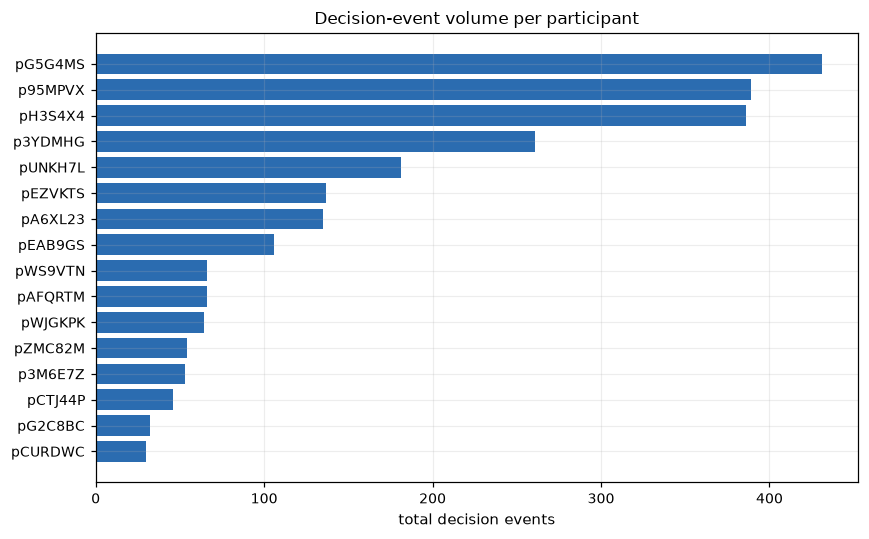

,n_decisions,n_kinds,n_sessions
participantId,,,
pCURDWC,30,13,1
pG2C8BC,32,13,1
pCTJ44P,46,14,1
p3M6E7Z,53,14,1
pZMC82M,54,14,1
pWJGKPK,64,14,1
pAFQRTM,66,14,2
pWS9VTN,66,13,2
pEAB9GS,106,13,3


In [18]:
avail = dec.groupby('participantId').agg(
    n_decisions=('kind', 'size'),
    n_kinds=('kind', 'nunique'),
    n_sessions=('sessionId', 'nunique'),
).sort_values('n_decisions')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(avail.index, avail['n_decisions'], color='#2b6cb0')
ax.set_xlabel('total decision events')
ax.set_title('Decision-event volume per participant')
plt.tight_layout()
plt.show()
plt.close(fig)
avail


## 9. Data-quality notes and rejected derivations

- **`screen_view` is not a useful second anchor.** It fires a median of 2ms after
  `task_start` (checked directly, Section 2) -- close enough to be noise, not a genuinely
  separate "decision presented" moment. `task_start` is the anchor used throughout.
- **`secure_approval_selected` has n=1 across the whole cohort.** One session used what looks
  like a tap-approve fallback instead of the swipe gesture (`approval_swipe_release`, n=135)
  everyone else used for the same task. Kept in the registry as a decision-*method* signal
  rather than excluded as noise, but it cannot support any statistic on its own.
- **`spending_card_selected` and `card_swipe_summary` are always correct by construction**
  (100% `targetCardSelected == True` in the current export) -- no accuracy variance exists to
  measure for these two kinds. Still potentially useful for latency and exposure.
- **Revision/re-selection within a task instance is essentially absent** (Section 5) with the
  current task design -- each decision kind fires once per task instance almost universally.
  This constrains what the notebook can say about hesitation-via-correction; hesitation-via-
  latency (Section 2) is the only version of this currently measurable.
- **`nav_tab_clicked` is not tied to a single task type** in the registry (`family = None`) --
  it can occur across multiple contexts, so it is excluded from the Section 6 affordance
  check, which assumes a one-to-one kind-to-task-family mapping.
- **Decision-to-action gap (Section 4) is only computed for `pot_drag`.**
  `approval_swipe_release` also follows a gesture, but no matching `gesture_swipe_start`-style
  event was found paired to it in this export -- worth checking against the app's own event
  schema before assuming it doesn't exist, rather than concluding it can't be measured.


## 10. Per-participant cards


In [19]:
for participant in sorted(dec['participantId'].unique()):
    sub = dec[dec['participantId'] == participant]
    n_sessions = df[df['participantId'] == participant]['sessionId'].nunique()
    print('=' * 60)
    print(participant, '| sessions:', n_sessions, '| total decisions:', len(sub))
    lat = sub['decision_latency_ms'].dropna()
    if len(lat) >= 3:
        print('  median decision latency:', round(lat.median(), 0), 'ms  (n=' + str(len(lat)) + ')')
    for kind, field in CORRECTNESS_KINDS.items():
        s = sub[sub['kind'] == kind].dropna(subset=[field]) if field in sub.columns else pd.DataFrame()
        if len(s) >= 2:
            acc = s[field].astype(bool).mean()
            print('  ' + kind + ' accuracy:', round(acc * 100, 0), '%  (n=' + str(len(s)) + ')')


p3M6E7Z | sessions: 1 | total decisions: 53
  median decision latency: 14186.0 ms  (n=53)
  category_selected accuracy: 100.0 %  (n=2)
  activity_filter_selected accuracy: 100.0 %  (n=2)
  pot_drag_release accuracy: 67.0 %  (n=3)
  approval_swipe_release accuracy: 100.0 %  (n=2)
  transaction_selected accuracy: 100.0 %  (n=2)
  merchant_option_selected accuracy: 14.0 %  (n=14)
p3YDMHG | sessions: 8 | total decisions: 261
  median decision latency: 5411.0 ms  (n=261)
  category_selected accuracy: 100.0 %  (n=16)
  activity_filter_selected accuracy: 100.0 %  (n=16)
  pot_drag_release accuracy: 97.0 %  (n=30)
  approval_swipe_release accuracy: 100.0 %  (n=16)
  transaction_selected accuracy: 100.0 %  (n=16)
  merchant_option_selected accuracy: 100.0 %  (n=22)
p95MPVX | sessions: 11 | total decisions: 389
  median decision latency: 5960.0 ms  (n=389)
  category_selected accuracy: 100.0 %  (n=22)
  activity_filter_selected accuracy: 96.0 %  (n=23)
  pot_drag_release accuracy: 92.0 %  (n=24)

## 11. Open questions

- **Whether decision latency is distinct from task-entry latency (Section 2) is reported
  directly from the correlation/scatter above, not asserted here** -- if they turn out tightly
  correlated at current cohort size, that may still change as more data comes in, and is worth
  re-checking once the dataset grows further.
- **Per-participant accuracy differences (Section 3) rest on very few attempts per person** --
  each decision kind occurs at most twice per session (pass 1 / pass 2), so single-session
  participants have at most 2 attempts at any one kind. This is a binding constraint on what
  Section 3 can currently say, not a flaw in the measurement itself.
- **The exposure-profile diagnostic (Section 7) is the result this notebook was specifically
  built to produce for the modelling-design discussion.** Whatever separability score it
  returned should be treated as a first read, re-run as the cohort grows, and used to decide
  the counts-vs-rates boundary in `build_windows_dataset.py`'s schema rather than argued about
  in the abstract.
- **Decision-to-action gap (Section 4) conflates motor duration and pre-release hesitation.**
  Whether the touchmove path within a pot-drag can separate "moving decisively toward the
  target" from "hovering near it before committing" is untested and would need per-sample
  path data, not just start/end timestamps.
- **Revision behaviour is absent with the current task design (Section 5), not necessarily
  absent from real banking-app use.** Worth keeping in mind if the task design is ever
  revised -- a task that allowed genuine re-selection would open up a decision-layer analogue
  to notebook 07's correction analysis, which currently has no counterpart here.
- **None of the decision-layer features here have been checked for within-person
  replication** -- the same standing check applied throughout this project (nb06 §12, nb07
  §13, nb09 §13) has not yet been run on decision latency or accuracy, and should be before
  either is trusted as a stable trait.
- **Every participant is still on their own device.** As with every notebook in this project,
  nothing here distinguishes a person's decision-making pattern from anything device- or
  session-length-mediated -- the exposure-profile diagnostic in Section 7 is a step toward
  making that risk visible, not a resolution of it.
